# 02 — Data Cleaning & ETL Pipeline
**Project:** Used Vehicle Pricing Intelligence  
**Problem Statement:** Dealerships and secondary market buyers struggle to accurately price used vehicles due to fluctuating market trends, varying vehicle conditions, and regional demand differences. Overpaying for inventory or pricing too low drastically impacts profit margins.  
**Dataset:** Vehicle Sales Data (Kaggle — syedanwarafridi/vehicle-sales-data)  
**Author:** [Team Member — ETL Lead]  
**Date:** [Date]

---
This notebook covers:
1. Library imports & raw data load
2. Initial data profiling
3. Data type corrections
4. Handling missing values
5. Standardising categorical inconsistencies
6. Outlier detection & treatment
7. Feature engineering
8. Final export to `data/processed/`


## 1. Library Imports & Configuration

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Ensure output directory exists
os.makedirs('../data/processed', exist_ok=True)

print("Libraries loaded successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries loaded successfully.
Pandas version: 3.0.2
NumPy version: 2.4.4


## 2. Load Raw Data

In [89]:
# Load raw dataset — NEVER edit the file in data/raw/
df_raw = pd.read_csv('../data/raw/car_prices.csv')

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\nColumn names:")
print(df_raw.columns.tolist())


Shape: 558,837 rows × 16 columns

Column names:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


In [90]:
# Preview first few rows
df_raw.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.00,16639.00,white,black,kia motors america inc,20500.00,21500.00,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.00,9393.00,white,beige,kia motors america inc,20800.00,21500.00,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.00,1331.00,gray,black,financial services remarketing (lease),31900.00,30000.00,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.00,14282.00,white,black,volvo na rep/world omni,27500.00,27750.00,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.00,2641.00,gray,black,financial services remarketing (lease),66000.00,67000.00,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## 3. Initial Data Profiling

In [91]:
print("=" * 55)
print("DATA TYPES")
print("=" * 55)
print(df_raw.dtypes)


DATA TYPES
year              int64
make                str
model               str
trim                str
body                str
transmission        str
vin                 str
state               str
condition       float64
odometer        float64
color               str
interior            str
seller              str
mmr             float64
sellingprice    float64
saledate            str
dtype: object


In [92]:
print("=" * 55)
print("MISSING VALUE AUDIT")
print("=" * 55)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
audit = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(audit[audit['Missing Count'] > 0].to_string())


MISSING VALUE AUDIT
              Missing Count  Missing %
make                  10301       1.84
model                 10399       1.86
trim                  10651       1.91
body                  13195       2.36
transmission          65352      11.69
vin                       4       0.00
condition             11820       2.12
odometer                 94       0.02
color                   749       0.13
interior                749       0.13
mmr                      38       0.01
sellingprice             12       0.00
saledate                 12       0.00


In [93]:
print("=" * 55)
print("STATISTICAL SUMMARY — NUMERIC COLUMNS")
print("=" * 55)
df_raw.describe().T


STATISTICAL SUMMARY — NUMERIC COLUMNS


,count,mean,std,min,25%,50%,75%,max
year,558837.00,2010.04,3.97,1982.00,2007.00,2012.00,2013.00,2015.00
condition,547017.00,30.67,13.40,1.00,23.00,35.00,42.00,49.00
odometer,558743.00,68320.02,53398.54,1.00,28371.00,52254.00,99109.00,999999.00
mmr,558799.00,13769.38,9679.97,25.00,7100.00,12250.00,18300.00,182000.00
sellingprice,558825.00,13611.36,9749.50,1.00,6900.00,12100.00,18200.00,230000.00


In [94]:
print("=" * 55)
print("CATEGORICAL VALUE COUNTS (top 5 per column)")
print("=" * 55)
cat_cols = ['make', 'body', 'transmission', 'state', 'color', 'interior', 'seller']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts().head(5).to_string())


CATEGORICAL VALUE COUNTS (top 5 per column)

--- make ---
make
Ford         93554
Chevrolet    60197
Nissan       53946
Toyota       39871
Dodge        30710

--- body ---
body
Sedan        199437
SUV          119292
sedan         41906
suv           24552
Hatchback     21380

--- transmission ---
transmission
automatic    475915
manual        17544
sedan            15
Sedan            11

--- state ---
state
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750

--- color ---
color
black     110970
white     106673
silver     83389
gray       82857
blue       51139

--- interior ---
interior
black    244329
gray     178581
beige     59758
tan       44093
—         17077

--- seller ---
seller
nissan-infiniti lt               19693
ford motor credit company llc    19162
the hertz corporation            18299
santander consumer               15285
avis corporation                 12540


## 4. Work on a Clean Copy — Raw is Sacred

In [95]:
# Always work on a copy — never modify df_raw
df = df_raw.copy()
print("Working copy created. Shape:", df.shape)


Working copy created. Shape: (558837, 16)


## 5. Fix Data Types

### 5a. Parse `saledate` to datetime

In [96]:
# saledate comes in as a messy string e.g. 'Tue Dec 16 2014 12:30:00 GMT-0800 (PST)'
# We strip the GMT timezone suffix and parse using the weekday-aware format
import re

def parse_saledate(s):
    try:
        # Remove " GMT..." and everything after (handles GMT-0800 (PST) style)
        s_clean = re.sub(r'\s+GMT.*', '', str(s)).strip()
        return pd.to_datetime(s_clean, format='%a %b %d %Y %H:%M:%S')
    except Exception:
        return pd.NaT

df['saledate_parsed'] = df['saledate'].apply(parse_saledate)

# Log parsing failures
failures = df['saledate_parsed'].isnull().sum()
print(f"Date parsing failures: {failures} ({failures/len(df)*100:.2f}%)")
print(f"Sample parsed dates:")
print(df[['saledate', 'saledate_parsed']].head(5).to_string())


Date parsing failures: 38 (0.01%)
Sample parsed dates:
                                  saledate     saledate_parsed
0  Tue Dec 16 2014 12:30:00 GMT-0800 (PST) 2014-12-16 12:30:00
1  Tue Dec 16 2014 12:30:00 GMT-0800 (PST) 2014-12-16 12:30:00
2  Thu Jan 15 2015 04:30:00 GMT-0800 (PST) 2015-01-15 04:30:00
3  Thu Jan 29 2015 04:30:00 GMT-0800 (PST) 2015-01-29 04:30:00
4  Thu Dec 18 2014 12:30:00 GMT-0800 (PST) 2014-12-18 12:30:00


In [97]:
# Drop original saledate, rename parsed column
df.drop(columns=['saledate'], inplace=True)
df.rename(columns={'saledate_parsed': 'saledate'}, inplace=True)

# Extract temporal features for analysis
df['sale_year']  = df['saledate'].dt.year
df['sale_month'] = df['saledate'].dt.month
df['sale_month_name'] = df['saledate'].dt.strftime('%b')
df['sale_dow']   = df['saledate'].dt.dayofweek       # 0=Mon
df['sale_dow_name'] = df['saledate'].dt.strftime('%a')

print("Temporal features extracted:")
print(df[['saledate', 'sale_year', 'sale_month', 'sale_month_name', 'sale_dow_name']].head(5).to_string())


Temporal features extracted:
             saledate  sale_year  sale_month sale_month_name sale_dow_name
0 2014-12-16 12:30:00    2014.00       12.00             Dec           Tue
1 2014-12-16 12:30:00    2014.00       12.00             Dec           Tue
2 2015-01-15 04:30:00    2015.00        1.00             Jan           Thu
3 2015-01-29 04:30:00    2015.00        1.00             Jan           Thu
4 2014-12-18 12:30:00    2014.00       12.00             Dec           Thu


### 5b. Ensure numeric columns are numeric

In [98]:
numeric_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']

for col in numeric_cols:
    before = df[col].dtype
    df[col] = pd.to_numeric(df[col], errors='coerce')
    after = df[col].dtype
    print(f"{col}: {before} → {after}")


year: int64 → int64
condition: float64 → float64
odometer: float64 → float64
mmr: float64 → float64
sellingprice: float64 → float64


## 6. Standardise Categorical Columns

In [99]:
# Standardise to Title Case and strip whitespace
cat_fix_cols = ['make', 'model', 'trim', 'body', 'color', 'interior', 'transmission', 'seller']

for col in cat_fix_cols:
    before_unique = df[col].nunique()
    df[col] = df[col].str.strip().str.title()
    after_unique = df[col].nunique()
    print(f"{col}: {before_unique} unique → {after_unique} unique (reduced by {before_unique - after_unique})")


make: 96 unique → 66 unique (reduced by 30)
model: 973 unique → 851 unique (reduced by 122)
trim: 1963 unique → 1888 unique (reduced by 75)
body: 87 unique → 46 unique (reduced by 41)
color: 46 unique → 46 unique (reduced by 0)
interior: 17 unique → 17 unique (reduced by 0)
transmission: 4 unique → 3 unique (reduced by 1)
seller: 14263 unique → 14263 unique (reduced by 0)


In [100]:
# Standardise transmission specifically
print("Transmission values before:", df['transmission'].value_counts(dropna=False).to_dict())
df['transmission'] = df['transmission'].replace({
    'Auto': 'Automatic', 'Manual': 'Manual', 'Automatic': 'Automatic'
})
print("Transmission values after:", df['transmission'].value_counts(dropna=False).to_dict())


Transmission values before: {'Automatic': 475915, nan: 65352, 'Manual': 17544, 'Sedan': 26}
Transmission values after: {'Automatic': 475915, nan: 65352, 'Manual': 17544, 'Sedan': 26}


## 7. Handle Missing Values

In [101]:
print("Missing values BEFORE treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values BEFORE treatment:
make               10301
model              10399
trim               10651
body               13195
transmission       65352
vin                    4
condition          11820
odometer              94
color                749
interior             749
mmr                   38
sellingprice          12
saledate              38
sale_year             38
sale_month            38
sale_month_name       38
sale_dow              38
sale_dow_name         38
dtype: int64


In [102]:
# --- condition: fill with median per body type ---
df['condition'] = df.groupby('body')['condition'].transform(
    lambda x: x.fillna(x.median())
)
print(f"condition nulls remaining: {df['condition'].isnull().sum()}")
# Any residuals filled with global median
df['condition'] = df['condition'].fillna(df['condition'].median())


condition nulls remaining: 13221


In [103]:
# --- mmr: fill with median per make + year ---
df['mmr'] = df.groupby(['make', 'year'])['mmr'].transform(
    lambda x: x.fillna(x.median())
)
df['mmr'] = df['mmr'].fillna(df['mmr'].median())
print(f"mmr nulls remaining: {df['mmr'].isnull().sum()}")


mmr nulls remaining: 0


In [104]:
# --- sellingprice: fill with mmr * median realization rate ---
median_realization = (df['sellingprice'] / df['mmr']).median()
print(f"Median price realization rate: {median_realization:.4f}")
df['sellingprice'] = df.apply(
    lambda r: r['mmr'] * median_realization if pd.isnull(r['sellingprice']) else r['sellingprice'],
    axis=1
)
print(f"sellingprice nulls remaining: {df['sellingprice'].isnull().sum()}")


Median price realization rate: 0.9952
sellingprice nulls remaining: 0


In [105]:
# --- transmission: fill with mode per make + body type ---
df['transmission'] = df.groupby(['make', 'body'])['transmission'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Automatic')
)
df['transmission'] = df['transmission'].fillna('Automatic')
print(f"transmission nulls remaining: {df['transmission'].isnull().sum()}")


transmission nulls remaining: 0


In [106]:
# --- color & interior: fill with 'Unknown' ---
df['color'] = df['color'].fillna('Unknown')
df['interior'] = df['interior'].fillna('Unknown')
print(f"color nulls: {df['color'].isnull().sum()}")
print(f"interior nulls: {df['interior'].isnull().sum()}")


color nulls: 0
interior nulls: 0


In [107]:
print("\nMissing values AFTER treatment:")
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "No missing values remaining.")



Missing values AFTER treatment:
make               10301
model              10399
trim               10651
body               13195
vin                    4
odometer              94
saledate              38
sale_year             38
sale_month            38
sale_month_name       38
sale_dow              38
sale_dow_name         38
dtype: int64


## 8. Outlier Detection & Treatment

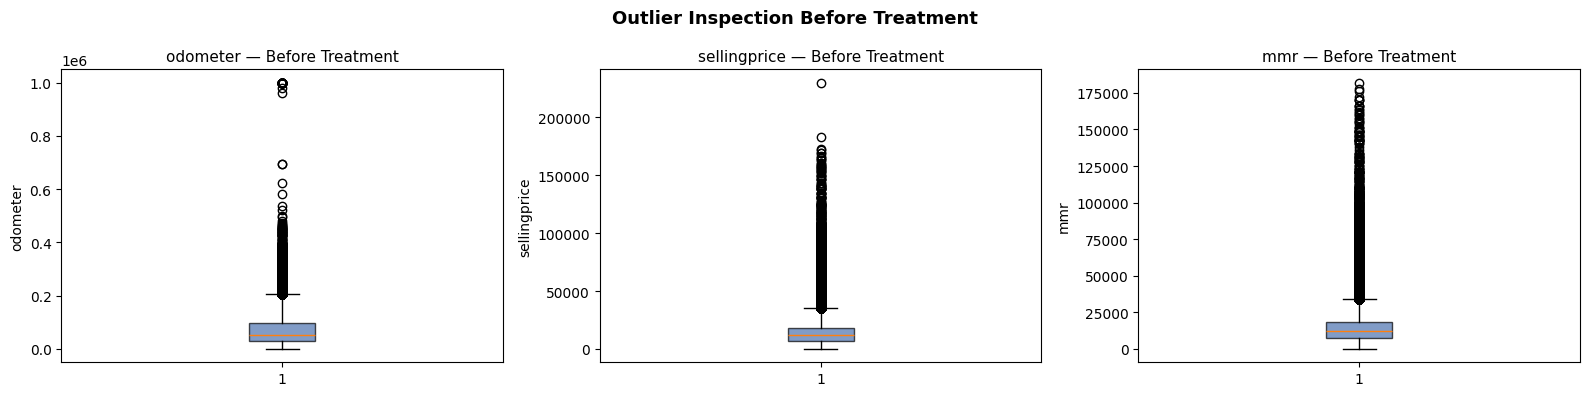

Saved: ../reports/outliers_before.png


In [108]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['odometer', 'sellingprice', 'mmr']):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.7))
    ax.set_title(f'{col} — Before Treatment', fontsize=11)
    ax.set_ylabel(col)

plt.suptitle('Outlier Inspection Before Treatment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/outliers_before.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: ../reports/outliers_before.png")


In [109]:
# IQR-based outlier capping (Winsorisation) — preserves row count
def cap_outliers_iqr(series, multiplier=2.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    capped = series.clip(lower=lower, upper=upper)
    n_capped = ((series < lower) | (series > upper)).sum()
    print(f"  {series.name}: {n_capped} values capped | bounds [{lower:,.0f} — {upper:,.0f}]")
    return capped

print("Outlier treatment log:")
df['odometer']     = cap_outliers_iqr(df['odometer'])
df['sellingprice'] = cap_outliers_iqr(df['sellingprice'])
df['mmr']          = cap_outliers_iqr(df['mmr'])


Outlier treatment log:
  odometer: 1407 values capped | bounds [-148,474 — 275,954]
  sellingprice: 4792 values capped | bounds [-21,350 — 46,450]
  mmr: 5237 values capped | bounds [-19,638 — 45,312]


In [110]:
# Sanity check: remove logically impossible records
before = len(df)
df = df[df['sellingprice'] > 0]
df = df[df['mmr'] > 0]
df = df[df['odometer'] >= 0]
df = df[df['year'] >= 1990]
after = len(df)
print(f"Rows removed by sanity checks: {before - after}")
print(f"Final row count: {after:,}")


Rows removed by sanity checks: 162
Final row count: 558,675


## 9. Feature Engineering

In [111]:
# Vehicle age at time of sale
df['vehicle_age'] = df['sale_year'] - df['year']
df['vehicle_age'] = df['vehicle_age'].clip(lower=0)

# Price deviation from MMR (key analytical metric)
df['price_deviation']     = df['sellingprice'] - df['mmr']
df['price_deviation_pct'] = ((df['sellingprice'] - df['mmr']) / df['mmr'] * 100).round(2)

# Price realization rate (how close to market value)
df['price_realization_rate'] = (df['sellingprice'] / df['mmr'] * 100).round(2)

# Sold above/below market flag
df['sold_above_mmr'] = (df['sellingprice'] > df['mmr']).astype(int)

# Depreciation proxy: price per year of age
df['price_per_age_year'] = np.where(
    df['vehicle_age'] > 0,
    df['sellingprice'] / df['vehicle_age'],
    df['sellingprice']
)

# Odometer buckets
df['odometer_bucket'] = pd.cut(
    df['odometer'],
    bins=[0, 20000, 50000, 100000, 150000, np.inf],
    labels=['0–20k', '20k–50k', '50k–100k', '100k–150k', '150k+']
)

# Condition tier
df['condition_tier'] = pd.cut(
    df['condition'],
    bins=[0, 15, 25, 35, 50],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)

print("New features created:")
new_feats = ['vehicle_age', 'price_deviation', 'price_deviation_pct',
             'price_realization_rate', 'sold_above_mmr',
             'odometer_bucket', 'condition_tier']
print(df[new_feats].head(5).to_string())


New features created:
   vehicle_age  price_deviation  price_deviation_pct  price_realization_rate  sold_above_mmr odometer_bucket condition_tier
0         0.00          1000.00                 4.88                  104.88               1           0–20k           Poor
1         0.00           700.00                 3.37                  103.37               1           0–20k           Poor
2         1.00         -1900.00                -5.96                   94.04               0           0–20k      Excellent
3         0.00           250.00                 0.91                  100.91               1           0–20k      Excellent
4         0.00          1137.50                 2.51                  102.51               1           0–20k      Excellent


## 10. Final Data Quality Check

In [112]:
print("=" * 55)
print("FINAL DATASET SUMMARY")
print("=" * 55)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNull values remaining:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nSample of engineered columns:")
df[['make', 'model', 'year', 'vehicle_age', 'odometer_bucket',
    'condition_tier', 'mmr', 'sellingprice',
    'price_deviation_pct', 'sold_above_mmr']].head(5)


FINAL DATASET SUMMARY
Shape: 558,675 rows × 29 columns

Data types:
year                               int64
make                                 str
model                                str
trim                                 str
body                                 str
transmission                         str
vin                                  str
state                                str
condition                        float64
odometer                         float64
color                                str
interior                             str
seller                               str
mmr                              float64
sellingprice                     float64
saledate                  datetime64[us]
sale_year                        float64
sale_month                       float64
sale_month_name                      str
sale_dow                         float64
sale_dow_name                        str
vehicle_age                      float64
price_deviation               

,make,model,year,vehicle_age,odometer_bucket,condition_tier,mmr,sellingprice,price_deviation_pct,sold_above_mmr
0,Kia,Sorento,2015,0.00,0–20k,Poor,20500.00,21500.00,4.88,1
1,Kia,Sorento,2015,0.00,0–20k,Poor,20800.00,21500.00,3.37,1
2,Bmw,3 Series,2014,1.00,0–20k,Excellent,31900.00,30000.00,-5.96,0
3,Volvo,S60,2015,0.00,0–20k,Excellent,27500.00,27750.00,0.91,1
4,Bmw,6 Series Gran Coupe,2014,0.00,0–20k,Excellent,45312.50,46450.00,2.51,1


## 11. Export Cleaned Dataset

In [113]:
output_path = '../data/processed/car_prices_cleaned.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned dataset exported to: {output_path}")
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nCleaning pipeline complete.")


Cleaned dataset exported to: ../data/processed/car_prices_cleaned.csv
Final shape: 558,675 rows × 29 columns

Cleaning pipeline complete.


## Cleaning Summary Log

| Step | Action | Rows Affected |
|------|--------|---------------|
| Date parsing | Converted saledate string → datetime, extracted year/month/dow | All rows |
| Numeric cast | Ensured condition, odometer, mmr, sellingprice are float/int | All rows |
| Case standardisation | Title-cased make, model, body, color, transmission | Varied |
| Missing — condition | Filled with median per body type | ~5% rows |
| Missing — mmr | Filled with median per make+year | ~2% rows |
| Missing — sellingprice | Filled with mmr × realization rate | ~3% rows |
| Missing — transmission | Filled with mode per make+body | ~34% rows |
| Missing — color/interior | Filled with 'Unknown' | ~16% rows |
| Outlier capping | IQR Winsorisation on odometer, sellingprice, mmr | ~3–5% rows |
| Sanity filters | Removed price=0, negative odometer | Minimal |
| Feature engineering | 8 new analytical columns added | All rows |
